In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'data').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / 'data').exists():
    raise FileNotFoundError('Não foi possível localizar a raiz do projeto.')

for candidate in [
    PROJECT_ROOT / 'code',
    PROJECT_ROOT / 'code' / 'revenue',
    PROJECT_ROOT / 'code' / 'tmdb',
]:
    if candidate.exists() and str(candidate.resolve()) not in sys.path:
        sys.path.append(str(candidate.resolve()))

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.ticker import FuncFormatter
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance

from experiment_utils import (
    ARTICLE_FIGURE_SIZES,
    MODEL_CONFIGS,
    RANDOM_SEED,
    TARGET_CONFIGS,
    apply_article_figure_theme,
    build_best_params_lookup,
    build_pipeline,
    build_model_from_best_params,
    clean_param_names,
    compute_summary,
    format_metric_mean_std,
    format_metric_value,
    format_summary_display,
    inverse_predictions,
    load_feature_matrix,
    load_processed_movies,
    load_saved_folds,
    load_saved_stratification_bins,
    make_holdout_split,
    serialize_params,
    show_and_save_current_figure,
)
from tmdb_feature_enrichment_utils import TMDB_EXTENDED_PROCESSED_DATA_PATH

/home/gabriel/Faculdade/Matérias/ML/UFSJ_Aprendizado_Maquina_TP1/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# **Predição de Receita com Base TMDB Estendida**

Este notebook repete o protocolo de regressão do projeto usando a base estendida com os novos metadados do TMDB (`data/TMDB_movies_processed_tmdb_extended.csv`).

As decisões metodológicas desta versão são:

- usar apenas a variável-alvo **sem transformação**;
- reutilizar exatamente os mesmos folds salvos em `data/revenue_folds.csv`;
- manter os mesmos modelos, grids e métricas do experimento original;
- salvar artefatos em uma pasta separada, para não sobrescrever o baseline.

In [2]:
DATASET_PATH = TMDB_EXTENDED_PROCESSED_DATA_PATH
NOTEBOOK_TARGET_NAME = 'Sem transformação'
NOTEBOOK_IMAGE_PREFIX = '05_tmdb_extended_no_transform'
NOTEBOOK_TABLE_PREFIX = NOTEBOOK_IMAGE_PREFIX

ARTIFACT_DIR = PROJECT_ROOT / 'data' / 'revenue_model_selection_tmdb_extended_no_transform'
RESULTS_PATH = ARTIFACT_DIR / 'model_selection_results.csv'
PREDICTIONS_PATH = ARTIFACT_DIR / 'model_selection_predictions.csv'
SUMMARY_PATH = ARTIFACT_DIR / 'model_selection_summary.csv'
BASELINE_COMPARISON_PATH = ARTIFACT_DIR / 'baseline_comparison_summary.csv'
TABLES_DIR = ARTIFACT_DIR / 'error_analysis'
TABLES_DIR.mkdir(parents=True, exist_ok=True)

BASELINE_SUMMARY_PATH = PROJECT_ROOT / 'data' / 'revenue_model_selection' / 'model_selection_summary.csv'
REVENUE_BAND_LABELS = [
    'Muito baixa receita',
    'Baixa receita',
    'Média receita',
    'Alta receita',
    'Muito alta receita',
]

In [3]:
df_movies = load_processed_movies(DATASET_PATH)
X, y = load_feature_matrix(df_movies)
saved_fold_assignments_df, folds_df, _ = load_saved_folds(df_movies)

print(f'Base carregada: {DATASET_PATH.name}')
print(f'Linhas: {df_movies.shape[0]} | Colunas: {df_movies.shape[1]}')
print(f'Total de features de entrada: {X.shape[1]}')
display(df_movies[['id_tmdb', 'title', 'revenue']].head())
display(saved_fold_assignments_df.head())
display(folds_df[['fold']].assign(n_test=folds_df['test_index'].map(len), n_train=folds_df['train_index'].map(len)))

Base carregada: TMDB_movies_processed_tmdb_extended.csv
Linhas: 6918 | Colunas: 287
Total de features de entrada: 284


,id_tmdb,title,revenue
0,552524,Lilo & Stitch,610800000
1,950387,A Minecraft Movie,947000000
2,1257960,सिकंदर,24727058
3,574475,Final Destination Bloodlines,229314062
4,1197306,A Working Man,98652557


,id_tmdb,fold
0,5,1
1,6,0
2,11,4
3,12,2
4,13,4


,fold,n_test,n_train
0,0,692,6226
1,1,692,6226
2,2,692,6226
3,3,692,6226
4,4,692,6226
5,5,692,6226
6,6,692,6226
7,7,692,6226
8,8,691,6227
9,9,691,6227


In [4]:
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

target_config = TARGET_CONFIGS[NOTEBOOK_TARGET_NAME]
fold_results = []
prediction_records = []

for model_name, config in MODEL_CONFIGS.items():
    print(f'=== {model_name} | {NOTEBOOK_TARGET_NAME} ===')

    for idx, row in folds_df.iterrows():
        train_idx = row['train_index']
        test_idx = row['test_index']

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        y_train_model = target_config['forward'](y_train)

        holdout_cv = make_holdout_split(X_train)

        grid_search = GridSearchCV(
            estimator=build_pipeline(clone(config['estimator'])),
            param_grid=config['param_grid'],
            scoring='neg_mean_squared_error',
            cv=holdout_cv,
            refit=True,
            verbose=0,
        )

        grid_search.fit(X_train, y_train_model)

        best_model = grid_search.best_estimator_
        best_params = clean_param_names(grid_search.best_params_)
        y_pred_model = best_model.predict(X_test)
        y_pred = inverse_predictions(y_pred_model, NOTEBOOK_TARGET_NAME)

        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        fold_results.append({
            'target_version': NOTEBOOK_TARGET_NAME,
            'model': model_name,
            'fold': idx,
            'mse': mse,
            'rmse': rmse,
            'mae': mae,
            'r2': r2,
            'best_params_json': serialize_params(best_params),
        })

        fold_predictions = pd.DataFrame({
            'row_index': test_idx,
            'id_tmdb': df_movies.iloc[test_idx]['id_tmdb'].values,
            'title': df_movies.iloc[test_idx]['title'].values,
            'target_version': NOTEBOOK_TARGET_NAME,
            'model': model_name,
            'fold': idx,
            'y_true': y_test,
            'y_pred': y_pred,
        })
        fold_predictions['residual'] = fold_predictions['y_true'] - fold_predictions['y_pred']
        fold_predictions['abs_error'] = fold_predictions['residual'].abs()
        prediction_records.append(fold_predictions)

        print(f'Fold {idx}: RMSE={rmse:.6f} | MAE={mae:.6f} | R²={r2:.6f}')
        print(f' - Best Params: {best_params}\n')

results_df = pd.DataFrame(fold_results)
predictions_df = pd.concat(prediction_records, ignore_index=True)
summary_table_df = compute_summary(results_df)
summary_df = summary_table_df.reset_index()
summary_display_df = format_summary_display(summary_table_df)

results_df.to_csv(RESULTS_PATH, index=False)
predictions_df.to_csv(PREDICTIONS_PATH, index=False)
summary_df.to_csv(SUMMARY_PATH, index=False)

print(f'Resultados salvos em: {RESULTS_PATH}')
print(f'Predições salvas em: {PREDICTIONS_PATH}')
print(f'Resumo salvo em: {SUMMARY_PATH}')

=== Dummy Regressor | Sem transformação ===
Fold 0: RMSE=145445029.669293 | MAE=97837583.088007 | R²=-0.002868
 - Best Params: {'strategy': 'mean'}

Fold 1: RMSE=187544735.805979 | MAE=103949672.371085 | R²=-0.000005
 - Best Params: {'strategy': 'mean'}

Fold 2: RMSE=187399868.977331 | MAE=102549811.896490 | R²=-0.000102
 - Best Params: {'strategy': 'mean'}

Fold 3: RMSE=212879889.769022 | MAE=107128795.817814 | R²=-0.000209
 - Best Params: {'strategy': 'mean'}

Fold 4: RMSE=179849187.418255 | MAE=106194580.941475 | R²=-0.000078
 - Best Params: {'strategy': 'mean'}

Fold 5: RMSE=203152300.710660 | MAE=106728743.009751 | R²=-0.000093
 - Best Params: {'strategy': 'mean'}

Fold 6: RMSE=165247003.506883 | MAE=101633368.814194 | R²=-0.000219
 - Best Params: {'strategy': 'mean'}

Fold 7: RMSE=193317507.641311 | MAE=106077587.158170 | R²=-0.000030
 - Best Params: {'strategy': 'mean'}

Fold 8: RMSE=182502925.738749 | MAE=107341959.546863 | R²=-0.000313
 - Best Params: {'strategy': 'mean'}

Fol

In [5]:
summary_display_df

MSE  \
Versão do alvo    Modelo                                               
Sem transformação XGBoost Regressor            1.27e+16 (± 3.59e+15)   
                  Gradient Boosting Regressor  1.29e+16 (± 3.61e+15)   
                  Random Forest Regressor      1.31e+16 (± 3.50e+15)   
                  Linear Regression            1.49e+16 (± 3.72e+15)   
                  KNN Regressor                1.85e+16 (± 3.53e+15)   
                  Decision Tree Regressor      1.92e+16 (± 4.13e+15)   
                  Dummy Regressor              3.45e+16 (± 6.79e+15)   
                  SVR                          3.86e+16 (± 7.10e+15)   

                                                                 RMSE  \
Versão do alvo    Modelo                                                
Sem transformação XGBoost Regressor            111.66 mi (± 15.00 mi)   
                  Gradient Boosting Regressor  112.71 mi (± 15.06 mi)   
                  Random Forest Regressor      113.78 mi (± 14.90 mi)   
                  Linear Regression            121.19 mi (± 15.06 mi)   
                  KNN Regressor                135.47 mi (± 13.32 mi)   
                  Decision Tree Regressor      137.73 mi (± 14.96 mi)   
                  Dummy Regressor              184.99 mi (± 18.95 mi)   
                  SVR                          195.71 mi (± 18.74 mi)   

                                                                 MAE  \
Versão do alvo    Modelo                                               
Sem transformação XGBoost Regressor             55.16 mi (± 2.52 mi)   
                  Gradient Boosting Regressor   55.70 mi (± 2.31 mi)   
                  Random Forest Regressor       55.22 mi (± 2.32 mi)   
                  Linear Regression             63.86 mi (± 2.14 mi)   
                  KNN Regressor                 66.93 mi (± 3.17 mi)   
                  Decision Tree Regressor       64.81 mi (± 2.61 mi)   
                  Dummy Regressor              104.67 mi (± 3.15 mi)   
                  SVR                           86.55 mi (± 3.11 mi)   

                                                             R²  
Versão do alvo    Modelo                                         
Sem transformação XGBoost Regressor             0.630 (± 0.078)  
                  Gradient Boosting Regressor   0.623 (± 0.083)  
                  Random Forest Regressor       0.615 (± 0.083)  
                  Linear Regression             0.569 (± 0.060)  
                  KNN Regressor                 0.460 (± 0.056)  
                  Decision Tree Regressor       0.409 (± 0.258)  
                  Dummy Regressor              -0.000 (± 0.001)  
                  SVR                          -0.121 (± 0.018)

In [6]:
if BASELINE_SUMMARY_PATH.exists():
    baseline_summary_df = pd.read_csv(BASELINE_SUMMARY_PATH)
    baseline_summary_df = baseline_summary_df.loc[baseline_summary_df['target_version'] == NOTEBOOK_TARGET_NAME].copy()

    comparison_df = baseline_summary_df.merge(
        summary_df,
        on=['target_version', 'model'],
        how='inner',
        suffixes=('_baseline', '_tmdb_extended'),
    )
    comparison_df['delta_rmse'] = comparison_df['mean_rmse_tmdb_extended'] - comparison_df['mean_rmse_baseline']
    comparison_df['delta_mae'] = comparison_df['mean_mae_tmdb_extended'] - comparison_df['mean_mae_baseline']
    comparison_df['delta_r2'] = comparison_df['mean_r2_tmdb_extended'] - comparison_df['mean_r2_baseline']
    comparison_df = comparison_df.sort_values(['mean_rmse_tmdb_extended', 'mean_mae_tmdb_extended', 'model']).reset_index(drop=True)
    comparison_df.to_csv(BASELINE_COMPARISON_PATH, index=False)

    comparison_display_df = comparison_df[[
        'model',
        'mean_rmse_baseline',
        'mean_rmse_tmdb_extended',
        'delta_rmse',
        'mean_mae_baseline',
        'mean_mae_tmdb_extended',
        'delta_mae',
        'mean_r2_baseline',
        'mean_r2_tmdb_extended',
        'delta_r2',
    ]].rename(columns={
        'model': 'Modelo',
        'mean_rmse_baseline': 'RMSE baseline',
        'mean_rmse_tmdb_extended': 'RMSE TMDB estendido',
        'delta_rmse': 'Δ RMSE',
        'mean_mae_baseline': 'MAE baseline',
        'mean_mae_tmdb_extended': 'MAE TMDB estendido',
        'delta_mae': 'Δ MAE',
        'mean_r2_baseline': 'R² baseline',
        'mean_r2_tmdb_extended': 'R² TMDB estendido',
        'delta_r2': 'Δ R²',
    })
    display(comparison_display_df)
    print(f'Comparação com o baseline salva em: {BASELINE_COMPARISON_PATH}')
else:
    print('Resumo do baseline original não encontrado; comparação pulada.')

,Modelo,RMSE baseline,RMSE TMDB estendido,Δ RMSE,MAE baseline,MAE TMDB estendido,Δ MAE,R² baseline,R² TMDB estendido,Δ R²
0,XGBoost Regressor,1.173215e+08,1.116649e+08,-5.656579e+06,5.893985e+07,5.515751e+07,-3.782336e+06,0.594043,0.630175,3.613197e-02
1,Gradient Boosting Regressor,1.201478e+08,1.127063e+08,-7.441561e+06,5.919208e+07,5.569888e+07,-3.493208e+06,0.570836,0.622988,5.215198e-02
2,Random Forest Regressor,1.193148e+08,1.137802e+08,-5.534626e+06,5.952976e+07,5.522204e+07,-4.307722e+06,0.578881,0.615321,3.644088e-02
3,Linear Regression,1.221821e+08,1.211899e+08,-9.921633e+05,6.362644e+07,6.385867e+07,2.322277e+05,0.561823,0.568643,6.819386e-03
4,KNN Regressor,1.308711e+08,1.354725e+08,4.601339e+06,6.695743e+07,6.692539e+07,-3.203388e+04,0.496622,0.460382,-3.624041e-02
5,Decision Tree Regressor,1.304415e+08,1.377342e+08,7.292688e+06,6.402764e+07,6.480930e+07,7.816585e+05,0.493589,0.408786,-8.480214e-02
6,Dummy Regressor,1.849913e+08,1.849913e+08,0.000000e+00,1.046663e+08,1.046663e+08,1.490116e-08,-0.000399,-0.000399,-4.721700e-17
7,SVR,1.957088e+08,1.957084e+08,-4.282274e+02,8.655492e+07,8.655454e+07,-3.766568e+02,-0.121231,-0.121226,4.804106e-06


Comparação com o baseline salva em: /home/gabriel/Faculdade/Matérias/ML/UFSJ_Aprendizado_Maquina_TP1/data/revenue_model_selection_tmdb_extended_no_transform/baseline_comparison_summary.csv


In [7]:
METRIC_RULES = [
    ('mean_mse', 'menor é melhor'),
    ('mean_rmse', 'menor é melhor'),
    ('mean_mae', 'menor é melhor'),
    ('mean_r2', 'maior é melhor'),
]
METRIC_LABELS = {
    'mean_mse': 'MSE',
    'mean_rmse': 'RMSE',
    'mean_mae': 'MAE',
    'mean_r2': 'R²',
}

def build_metric_winners_table(summary_source_df):
    winner_rows = []

    for metric_name, rule_label in METRIC_RULES:
        if rule_label == 'maior é melhor':
            ordered_df = summary_source_df.sort_values(
                by=[metric_name, 'mean_rmse', 'mean_mae', 'model'],
                ascending=[False, True, True, True]
            )
        else:
            ordered_df = summary_source_df.sort_values(
                by=[metric_name, 'mean_rmse', 'mean_mae', 'model'],
                ascending=[True, True, True, True]
            )

        winner = ordered_df.iloc[0]
        winner_rows.append({
            'metric': metric_name,
            'rule': rule_label,
            'winning_model': winner['model'],
        })

    metric_winners_df = pd.DataFrame(winner_rows)
    winner_counts_df = (
        metric_winners_df['winning_model']
        .value_counts()
        .rename_axis('model')
        .reset_index(name='n_metric_wins')
    )
    winner_metrics_df = (
        metric_winners_df
        .groupby('winning_model')['metric']
        .agg(lambda values: ', '.join(METRIC_LABELS[value] for value in values))
        .rename('metrics_won')
        .reset_index()
        .rename(columns={'winning_model': 'model'})
    )
    winner_counts_df = winner_counts_df.merge(winner_metrics_df, on='model', how='left')
    winner_counts_df = winner_counts_df.merge(
        summary_source_df[['model', 'mean_mse', 'mean_rmse', 'mean_mae', 'mean_r2']],
        on='model',
        how='left'
    )
    winner_counts_df = winner_counts_df.sort_values(
        ['n_metric_wins', 'mean_rmse', 'mean_mae', 'mean_r2', 'model'],
        ascending=[False, True, True, False, True]
    ).reset_index(drop=True)

    return metric_winners_df, winner_counts_df

def build_metric_winners_display(metric_winners_df, summary_source_df):
    summary_lookup_df = summary_source_df.set_index('model')
    display_rows = []

    for row in metric_winners_df.itertuples(index=False):
        metric_suffix = row.metric.replace('mean_', '')
        winner_summary = summary_lookup_df.loc[row.winning_model]
        display_rows.append({
            'Métrica': METRIC_LABELS[row.metric],
            'Regra': row.rule,
            'Modelo vencedor': row.winning_model,
            'Valor (média ± dp)': format_metric_mean_std(
                winner_summary[f'mean_{metric_suffix}'],
                winner_summary[f'std_{metric_suffix}'],
                metric_suffix,
            ),
        })

    return pd.DataFrame(display_rows)

metric_winners_df, winner_counts_df = build_metric_winners_table(summary_df.copy())
best_row = winner_counts_df.iloc[0]
best_model_name = best_row['model']

selected_model_overview_df = pd.DataFrame({
    'Versão do alvo': [NOTEBOOK_TARGET_NAME],
    'Modelo selecionado': [best_model_name],
    'Vitórias em métricas': [int(best_row['n_metric_wins'])],
    'Métricas vencidas': [best_row['metrics_won']],
})
metric_winners_display_df = build_metric_winners_display(metric_winners_df, summary_df.copy())

display(selected_model_overview_df)
display(metric_winners_display_df)

,Versão do alvo,Modelo selecionado,Vitórias em métricas,Métricas vencidas
0,Sem transformação,XGBoost Regressor,4,"MSE, RMSE, MAE, R²"


,Métrica,Regra,Modelo vencedor,Valor (média ± dp)
0,MSE,menor é melhor,XGBoost Regressor,1.27e+16 (± 3.59e+15)
1,RMSE,menor é melhor,XGBoost Regressor,111.66 mi (± 15.00 mi)
2,MAE,menor é melhor,XGBoost Regressor,55.16 mi (± 2.52 mi)
3,R²,maior é melhor,XGBoost Regressor,0.630 (± 0.078)


In [8]:
best_model_predictions_df = (
    predictions_df.loc[predictions_df['model'] == best_model_name]
    .sort_values(['fold', 'row_index'])
    .reset_index(drop=True)
)

best_params_per_model = build_best_params_lookup(results_df)
all_best_models = []

for idx, row in folds_df.iterrows():
    train_idx = row['train_index']
    test_idx = row['test_index']

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    y_train_model = TARGET_CONFIGS[NOTEBOOK_TARGET_NAME]['forward'](y_train)
    y_test_model = TARGET_CONFIGS[NOTEBOOK_TARGET_NAME]['forward'](y_test)

    model = build_model_from_best_params(
        best_model_name,
        best_params_per_model[NOTEBOOK_TARGET_NAME][best_model_name][idx]
    )
    model.fit(X_train, y_train_model)
    all_best_models.append((model, X_test.copy(), y_test_model.copy()))

display(best_model_predictions_df.head())

,row_index,id_tmdb,title,target_version,model,fold,y_true,y_pred,residual,abs_error
0,7,1233413,Sinners,Sem transformação,XGBoost Regressor,0,350000000,5.026333e+08,-1.526333e+08,1.526333e+08
1,12,896536,The Legend of Ochi,Sem transformação,XGBoost Regressor,0,4588865,1.025161e+06,3.563704e+06,3.563704e+06
2,13,986056,Thunderbolts*,Sem transformação,XGBoost Regressor,0,369507728,3.250539e+08,4.445387e+07,4.445387e+07
3,17,762509,Mufasa: The Lion King,Sem transformação,XGBoost Regressor,0,721046090,1.020012e+09,-2.989663e+08,2.989663e+08
4,21,374720,Dunkirk,Sem transformação,XGBoost Regressor,0,527000000,4.313001e+08,9.569990e+07,9.569990e+07


In [9]:
apply_article_figure_theme()
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')

current_model_label = f'{best_model_name} | {NOTEBOOK_TARGET_NAME} | TMDB estendido'

error_analysis_df = best_model_predictions_df.copy()
error_analysis_df['signed_percentage_error'] = np.where(
    error_analysis_df['y_true'] != 0,
    100 * error_analysis_df['residual'] / error_analysis_df['y_true'],
    np.nan,
)

def format_currency_millions(value):
    if pd.isna(value):
        return '-'
    return f'US$ {value / 1_000_000:,.2f} mi'

def format_percentage(value):
    if pd.isna(value):
        return '-'
    return f'{value:.1f}%'

def millions_formatter(value, _position):
    return f'US$ {value / 1_000_000:,.0f} mi'

def apply_revenue_bands(df, bins):
    result = df.copy()
    result['faixa_receita'] = pd.cut(
        result['y_true'],
        bins=bins,
        labels=REVENUE_BAND_LABELS,
        include_lowest=True,
    )
    result['faixa_receita'] = pd.Categorical(
        result['faixa_receita'],
        categories=REVENUE_BAND_LABELS,
        ordered=True,
    )
    return result

def summarize_errors_by_band(df, group_cols=None):
    group_cols = list(group_cols or [])
    grouped = (
        df.groupby(group_cols + ['faixa_receita'], observed=False)
        .agg(
            quantidade_filmes=('row_index', 'size'),
            receita_minima=('y_true', 'min'),
            receita_maxima=('y_true', 'max'),
            mae_medio=('abs_error', 'mean'),
            mse=('residual', lambda values: np.mean(np.square(values))),
            residuo_medio=('residual', 'mean'),
            mediana_erro_absoluto=('abs_error', 'median'),
            percentual_subestimados=('residual', lambda values: (values > 0).mean() * 100),
            percentual_superestimados=('residual', lambda values: (values < 0).mean() * 100),
        )
        .reset_index()
    )
    grouped['rmse'] = np.sqrt(grouped.pop('mse'))
    return grouped

def build_display_table(df, monetary_columns, percentage_columns):
    display_df = df.copy()
    for column in monetary_columns:
        display_df[column] = display_df[column].map(format_currency_millions)
    for column in percentage_columns:
        display_df[column] = display_df[column].map(format_percentage)
    return display_df

def save_table_versions(df, stem, monetary_columns, percentage_columns):
    raw_path = TABLES_DIR / f'{stem}_raw.csv'
    formatted_path = TABLES_DIR / f'{stem}_formatado.csv'
    df.to_csv(raw_path, index=False)
    build_display_table(
        df,
        monetary_columns=monetary_columns,
        percentage_columns=percentage_columns,
    ).to_csv(formatted_path, index=False)
    return raw_path, formatted_path

PLOT_COLORS = {
    'blue': '#4c6a92',
    'navy': '#2f6690',
    'red': '#8c1c13',
    'text': '#243746',
}
BAND_PALETTE = {
    'Muito baixa receita': '#b8ddd4',
    'Baixa receita': '#8fc8bb',
    'Média receita': '#5fb3b3',
    'Alta receita': '#3f88c5',
    'Muito alta receita': '#225ea8',
}

def style_axis(ax, xlabel, ylabel, *, xrotation=0, grid_axis='both'):
    ax.set_xlabel(xlabel, fontsize=ARTICLE_FIGURE_SIZES['axis_label'], fontweight='semibold', labelpad=10)
    ax.set_ylabel(ylabel, fontsize=ARTICLE_FIGURE_SIZES['axis_label'], fontweight='semibold', labelpad=10)
    ax.tick_params(axis='x', labelsize=ARTICLE_FIGURE_SIZES['tick'])
    ax.tick_params(axis='y', labelsize=ARTICLE_FIGURE_SIZES['tick'])
    plt.setp(ax.get_xticklabels(), rotation=xrotation, ha='right' if xrotation else 'center')
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('semibold')
    if grid_axis == 'both':
        ax.grid(True, linestyle='--', alpha=0.28)
    else:
        ax.grid(axis=grid_axis, linestyle='--', alpha=0.28)
    sns.despine(ax=ax)

def add_bar_value_labels(ax, values):
    values = list(values)
    offset = max(values) * 0.015 if values else 0
    for i, value in enumerate(values):
        ax.text(
            i,
            value + offset,
            format_currency_millions(value),
            ha='center',
            va='bottom',
            fontsize=ARTICLE_FIGURE_SIZES['annotation_small'],
            fontweight='semibold',
            color=PLOT_COLORS['text'],
        )

def style_band_legend(legend):
    if legend is None:
        return
    frame = legend.get_frame()
    frame.set_edgecolor('#c7c7c7')
    frame.set_linewidth(1.0)
    frame.set_alpha(0.96)

Figura: Análise de erros do melhor modelo com base TMDB estendida (painéis: valores reais vs preditos, distribuição dos resíduos e resíduos vs predições)


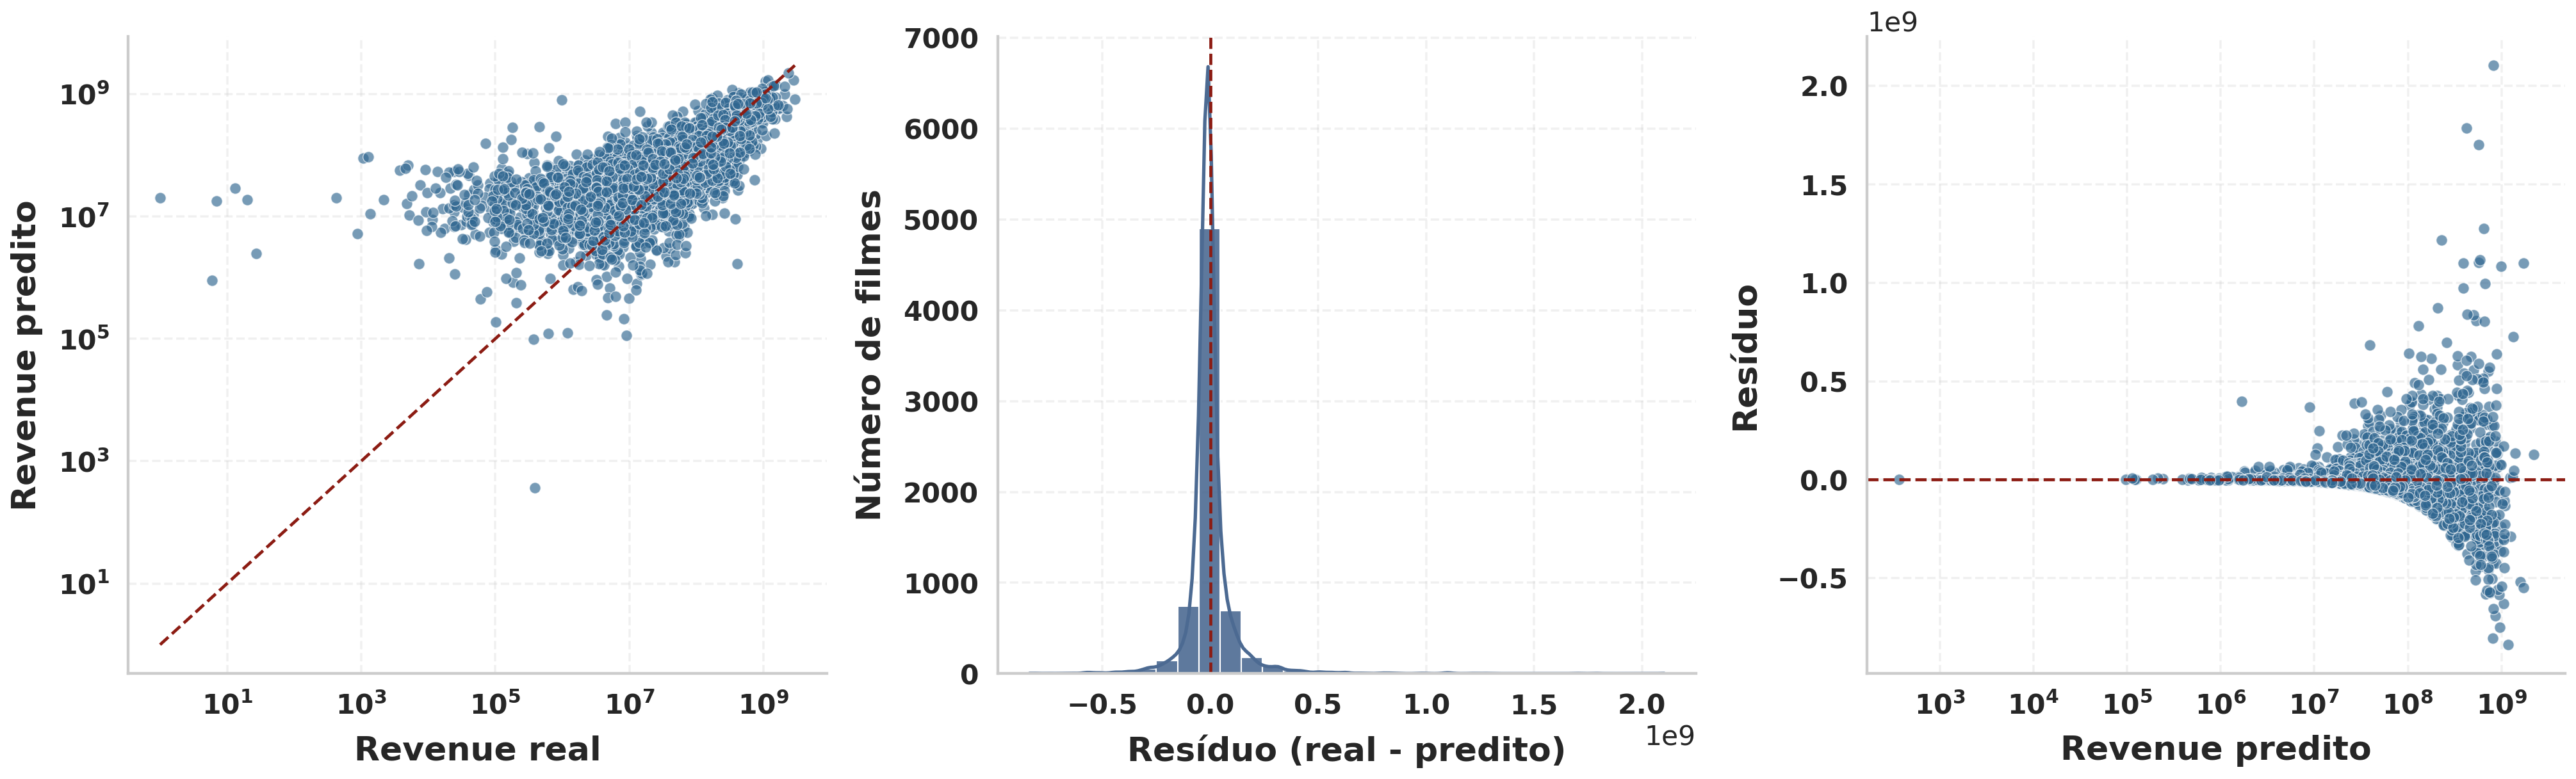

PosixPath('/home/gabriel/Faculdade/Matérias/ML/UFSJ_Aprendizado_Maquina_TP1/code/revenue/images/05_tmdb_extended_no_transform_analise_de_erros_melhor_modelo.png')

In [10]:
figure_title = (
    'Análise de erros do melhor modelo com base TMDB estendida '
    '(painéis: valores reais vs preditos, distribuição dos resíduos e resíduos vs predições)'
)
apply_article_figure_theme()
fig, axes = plt.subplots(1, 3, figsize=(24, 7.5))

max_axis_value = max(error_analysis_df['y_true'].max(), error_analysis_df['y_pred'].max())
min_axis_value = max(min(error_analysis_df['y_true'].min(), error_analysis_df['y_pred'].min()), 1)

sns.scatterplot(
    data=error_analysis_df,
    x='y_true',
    y='y_pred',
    color='#2f6690',
    alpha=0.65,
    s=55,
    ax=axes[0]
)
axes[0].plot([min_axis_value, max_axis_value], [min_axis_value, max_axis_value], linestyle='--', color='#8c1c13', linewidth=2)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Revenue real', fontsize=ARTICLE_FIGURE_SIZES['axis_label'], fontweight='semibold', labelpad=10)
axes[0].set_ylabel('Revenue predito', fontsize=ARTICLE_FIGURE_SIZES['axis_label'], fontweight='semibold', labelpad=10)

sns.histplot(
    error_analysis_df['residual'],
    bins=30,
    kde=True,
    color='#4c6a92',
    edgecolor='white',
    linewidth=0.9,
    alpha=0.9,
    ax=axes[1]
)
axes[1].axvline(0, linestyle='--', color='#8c1c13', linewidth=2)
axes[1].set_xlabel('Resíduo (real - predito)', fontsize=ARTICLE_FIGURE_SIZES['axis_label'], fontweight='semibold', labelpad=10)
axes[1].set_ylabel('Número de filmes', fontsize=ARTICLE_FIGURE_SIZES['axis_label'], fontweight='semibold', labelpad=10)

sns.scatterplot(
    data=error_analysis_df,
    x='y_pred',
    y='residual',
    color='#2f6690',
    alpha=0.65,
    s=55,
    ax=axes[2]
)
axes[2].axhline(0, linestyle='--', color='#8c1c13', linewidth=2)
axes[2].set_xscale('log')
axes[2].set_xlabel('Revenue predito', fontsize=ARTICLE_FIGURE_SIZES['axis_label'], fontweight='semibold', labelpad=10)
axes[2].set_ylabel('Resíduo', fontsize=ARTICLE_FIGURE_SIZES['axis_label'], fontweight='semibold', labelpad=10)

for ax in axes:
    ax.tick_params(axis='x', labelsize=ARTICLE_FIGURE_SIZES['tick'])
    ax.tick_params(axis='y', labelsize=ARTICLE_FIGURE_SIZES['tick'])
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('semibold')
    ax.grid(True, linestyle='--', alpha=0.28)
    sns.despine(ax=ax)

plt.tight_layout()
show_and_save_current_figure(
    f'{NOTEBOOK_IMAGE_PREFIX}_analise_de_erros_melhor_modelo',
    notebook_title=figure_title,
)

In [11]:
revenue_bins = load_saved_stratification_bins()
if len(revenue_bins) - 1 != len(REVENUE_BAND_LABELS):
    raise ValueError('Os bins salvos da estratificação não correspondem à quantidade de faixas configurada no notebook.')

error_analysis_df = apply_revenue_bands(error_analysis_df, revenue_bins)

band_metrics_raw_df = (
    summarize_errors_by_band(error_analysis_df)
    .sort_values('faixa_receita')
    .reset_index(drop=True)
)

band_metrics_display_df = build_display_table(
    band_metrics_raw_df,
    monetary_columns=[
        'receita_minima',
        'receita_maxima',
        'mae_medio',
        'rmse',
        'residuo_medio',
        'mediana_erro_absoluto',
    ],
    percentage_columns=['percentual_subestimados', 'percentual_superestimados'],
).rename(columns={
    'faixa_receita': 'Faixa de receita',
    'quantidade_filmes': 'Quantidade de filmes',
    'receita_minima': 'Receita mínima',
    'receita_maxima': 'Receita máxima',
    'mae_medio': 'MAE médio',
    'rmse': 'RMSE',
    'residuo_medio': 'Resíduo médio',
    'mediana_erro_absoluto': 'Mediana do erro absoluto',
    'percentual_subestimados': '% de subestimação',
    'percentual_superestimados': '% de superestimação',
})

band_metrics_raw_path, band_metrics_display_path = save_table_versions(
    band_metrics_raw_df,
    stem=f'{NOTEBOOK_TABLE_PREFIX}_metricas_por_faixa',
    monetary_columns=[
        'receita_minima',
        'receita_maxima',
        'mae_medio',
        'rmse',
        'residuo_medio',
        'mediana_erro_absoluto',
    ],
    percentage_columns=['percentual_subestimados', 'percentual_superestimados'],
)

print(f'Modelo analisado: {current_model_label}')
display(band_metrics_display_df)
print(f'Arquivos salvos: {band_metrics_raw_path} | {band_metrics_display_path}')

Modelo analisado: XGBoost Regressor | Sem transformação | TMDB estendido


,Faixa de receita,Quantidade de filmes,Receita mínima,Receita máxima,MAE médio,Resíduo médio,Mediana do erro absoluto,% de subestimação,% de superestimação,RMSE
0,Muito baixa receita,1384,US$ 0.00 mi,US$ 7.09 mi,US$ 22.42 mi,US$ -22.00 mi,US$ 14.59 mi,10.6%,89.4%,US$ 40.67 mi
1,Baixa receita,1383,US$ 7.10 mi,US$ 22.44 mi,US$ 28.53 mi,US$ -26.71 mi,US$ 20.45 mi,12.7%,87.3%,US$ 44.26 mi
2,Média receita,1384,US$ 22.47 mi,US$ 52.80 mi,US$ 30.25 mi,US$ -21.83 mi,US$ 18.46 mi,31.5%,68.5%,US$ 48.59 mi
3,Alta receita,1383,US$ 52.90 mi,US$ 134.04 mi,US$ 41.33 mi,US$ -2.84 mi,US$ 31.43 mi,58.3%,41.7%,US$ 60.70 mi
4,Muito alta receita,1384,US$ 134.10 mi,"US$ 2,923.71 mi",US$ 153.22 mi,US$ 71.02 mi,US$ 106.75 mi,70.5%,29.5%,US$ 231.70 mi


Arquivos salvos: /home/gabriel/Faculdade/Matérias/ML/UFSJ_Aprendizado_Maquina_TP1/data/revenue_model_selection_tmdb_extended_no_transform/error_analysis/05_tmdb_extended_no_transform_metricas_por_faixa_raw.csv | /home/gabriel/Faculdade/Matérias/ML/UFSJ_Aprendizado_Maquina_TP1/data/revenue_model_selection_tmdb_extended_no_transform/error_analysis/05_tmdb_extended_no_transform_metricas_por_faixa_formatado.csv


Figura: MAE por faixa de receita


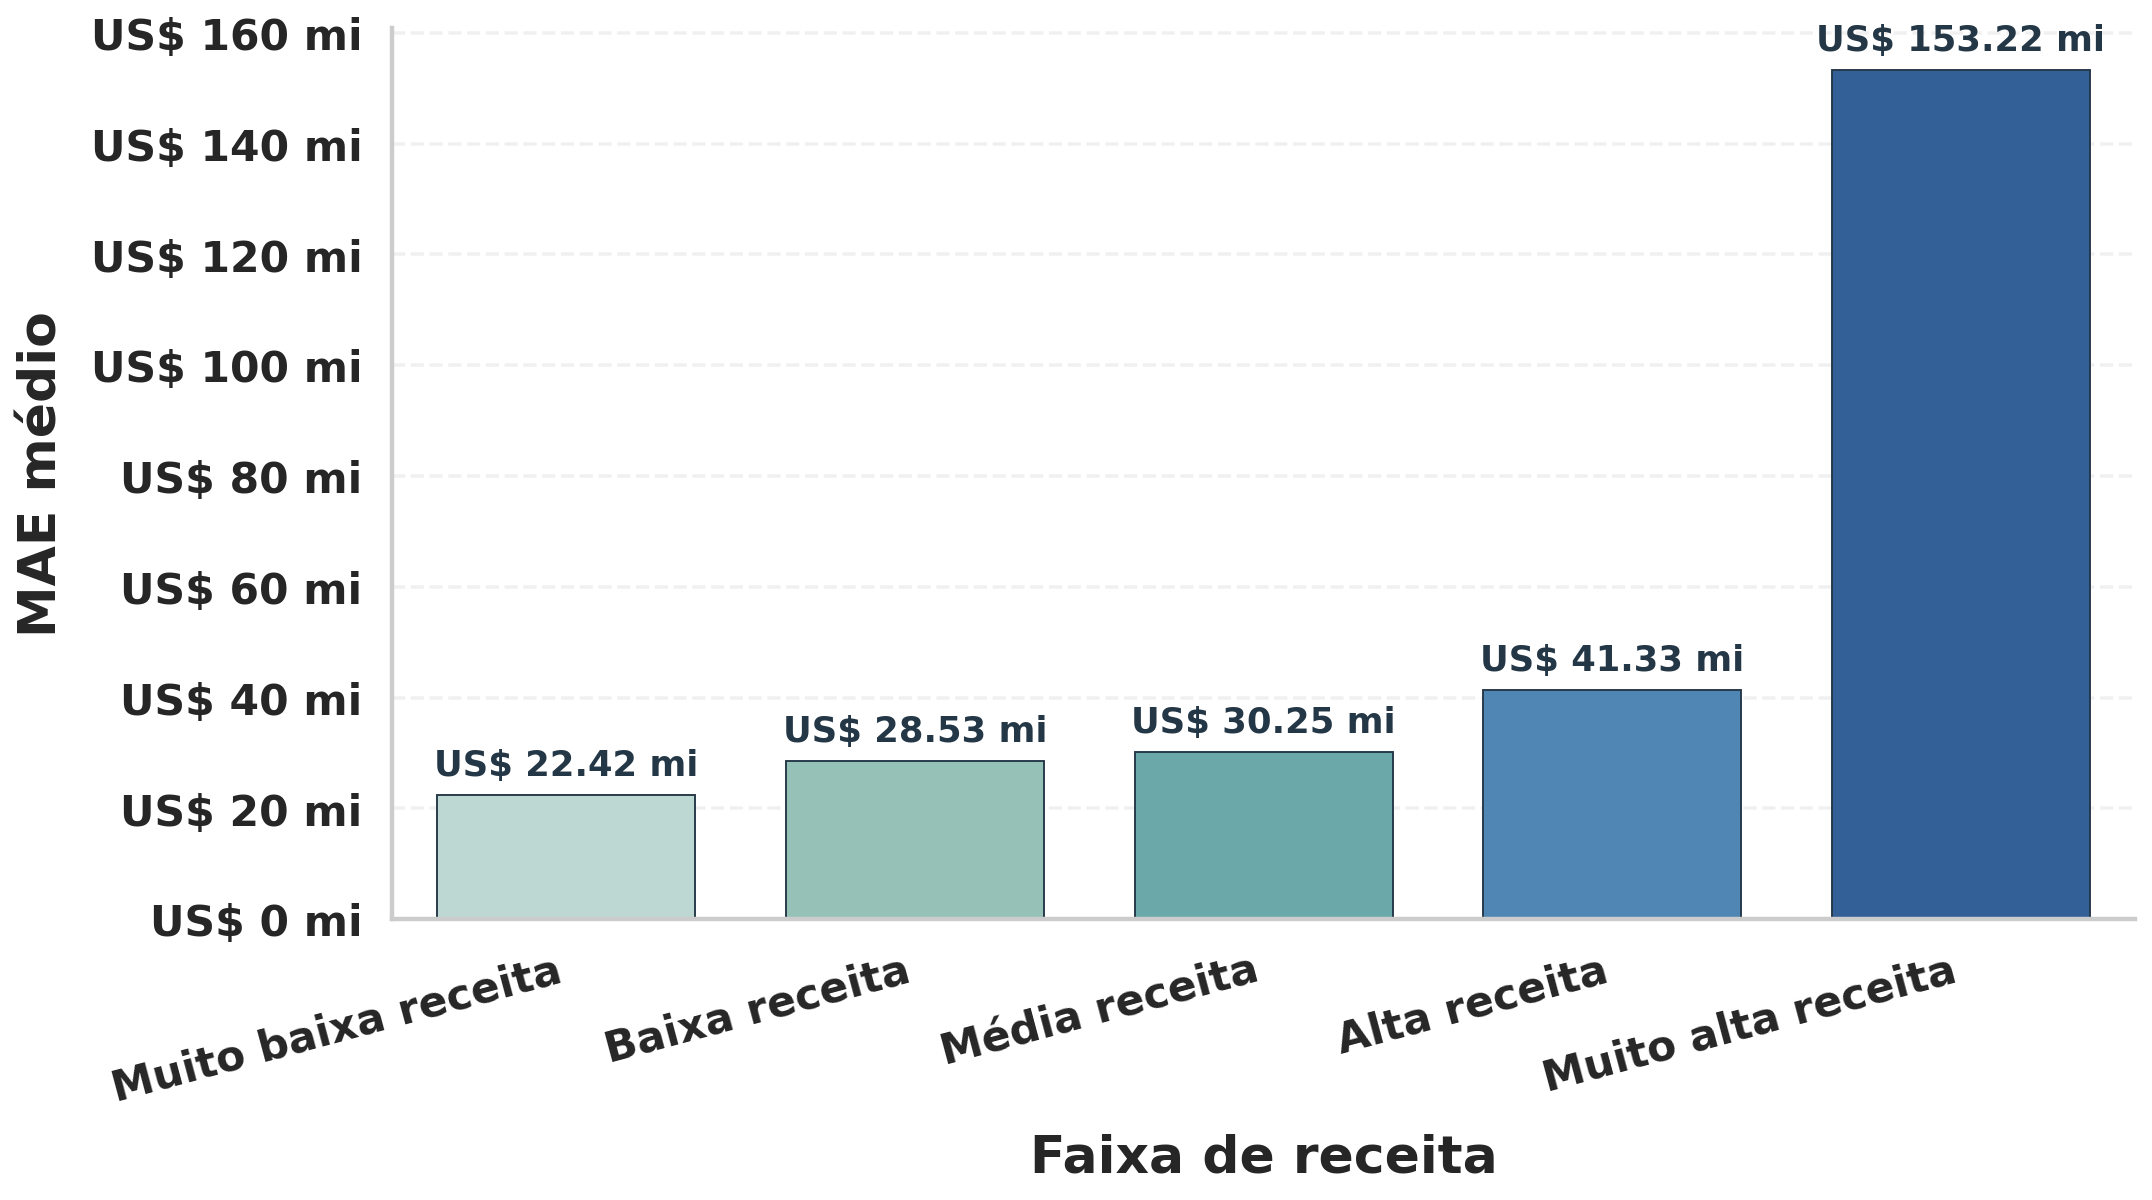

Figura: Distribuição do erro absoluto por faixa de receita


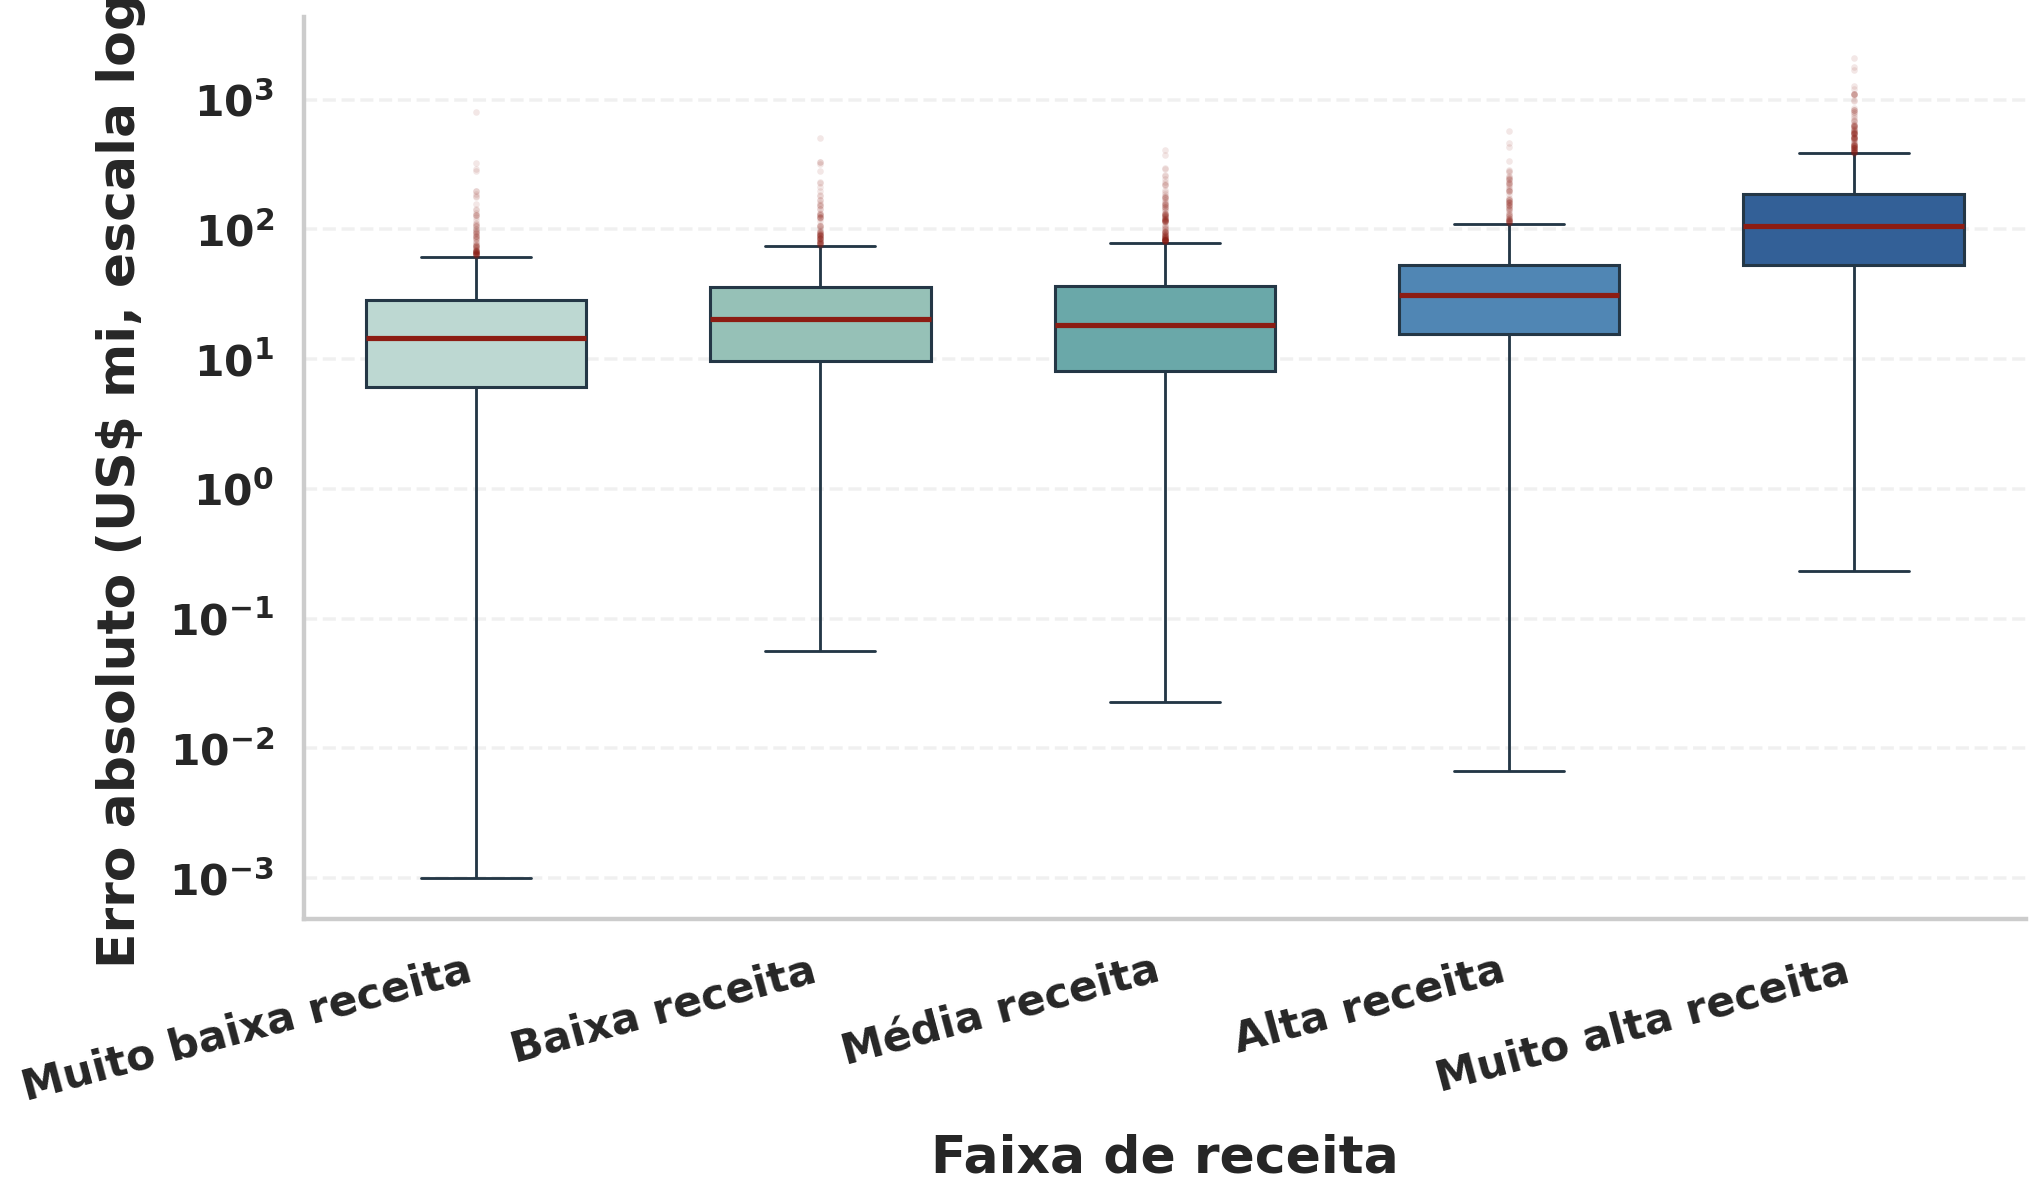

Figura: Valores reais vs preditos por faixa de receita


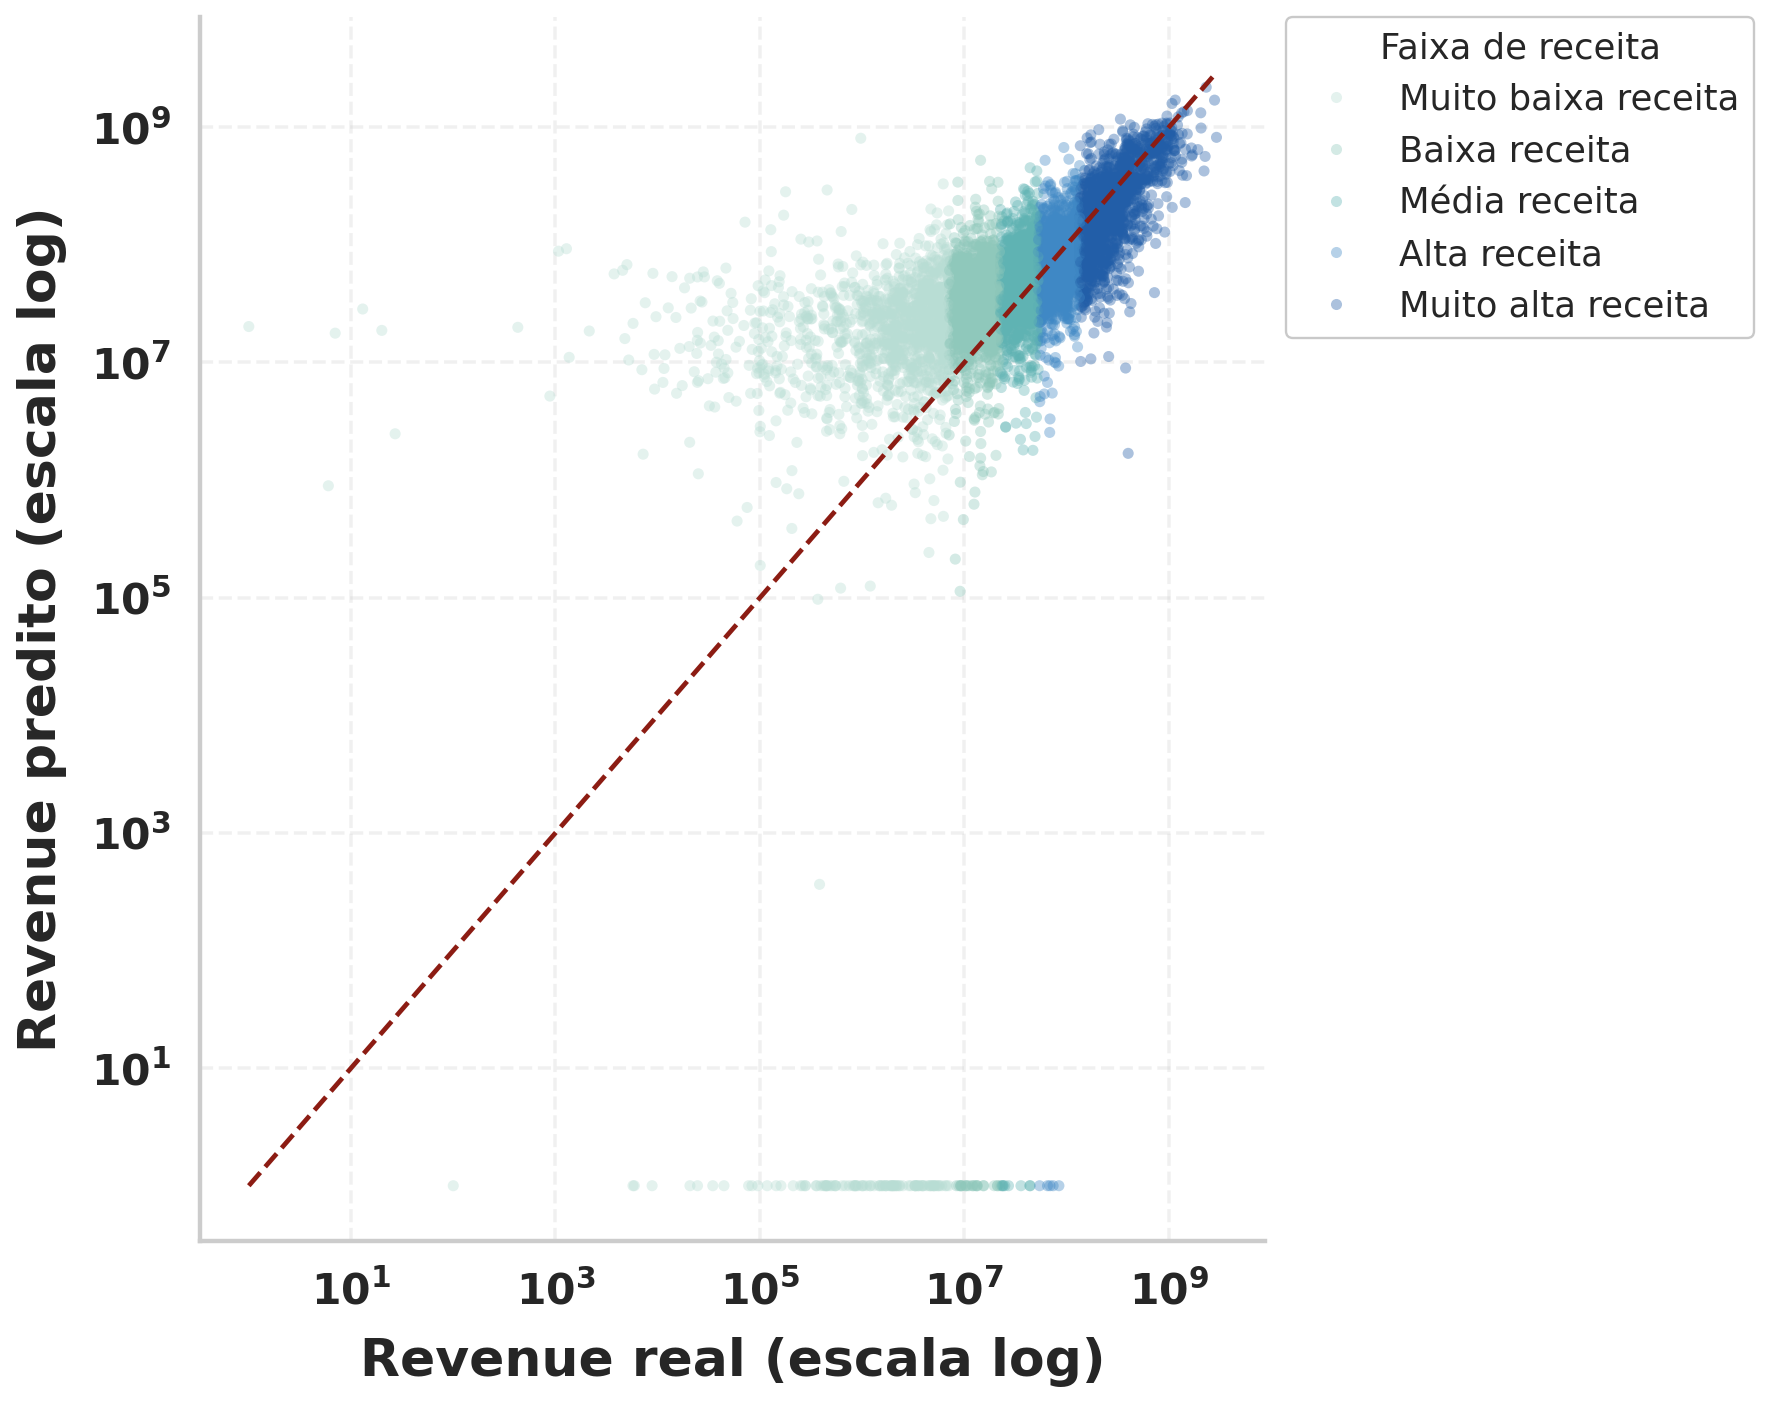

Figura: Resíduos em função da receita real por faixa de receita


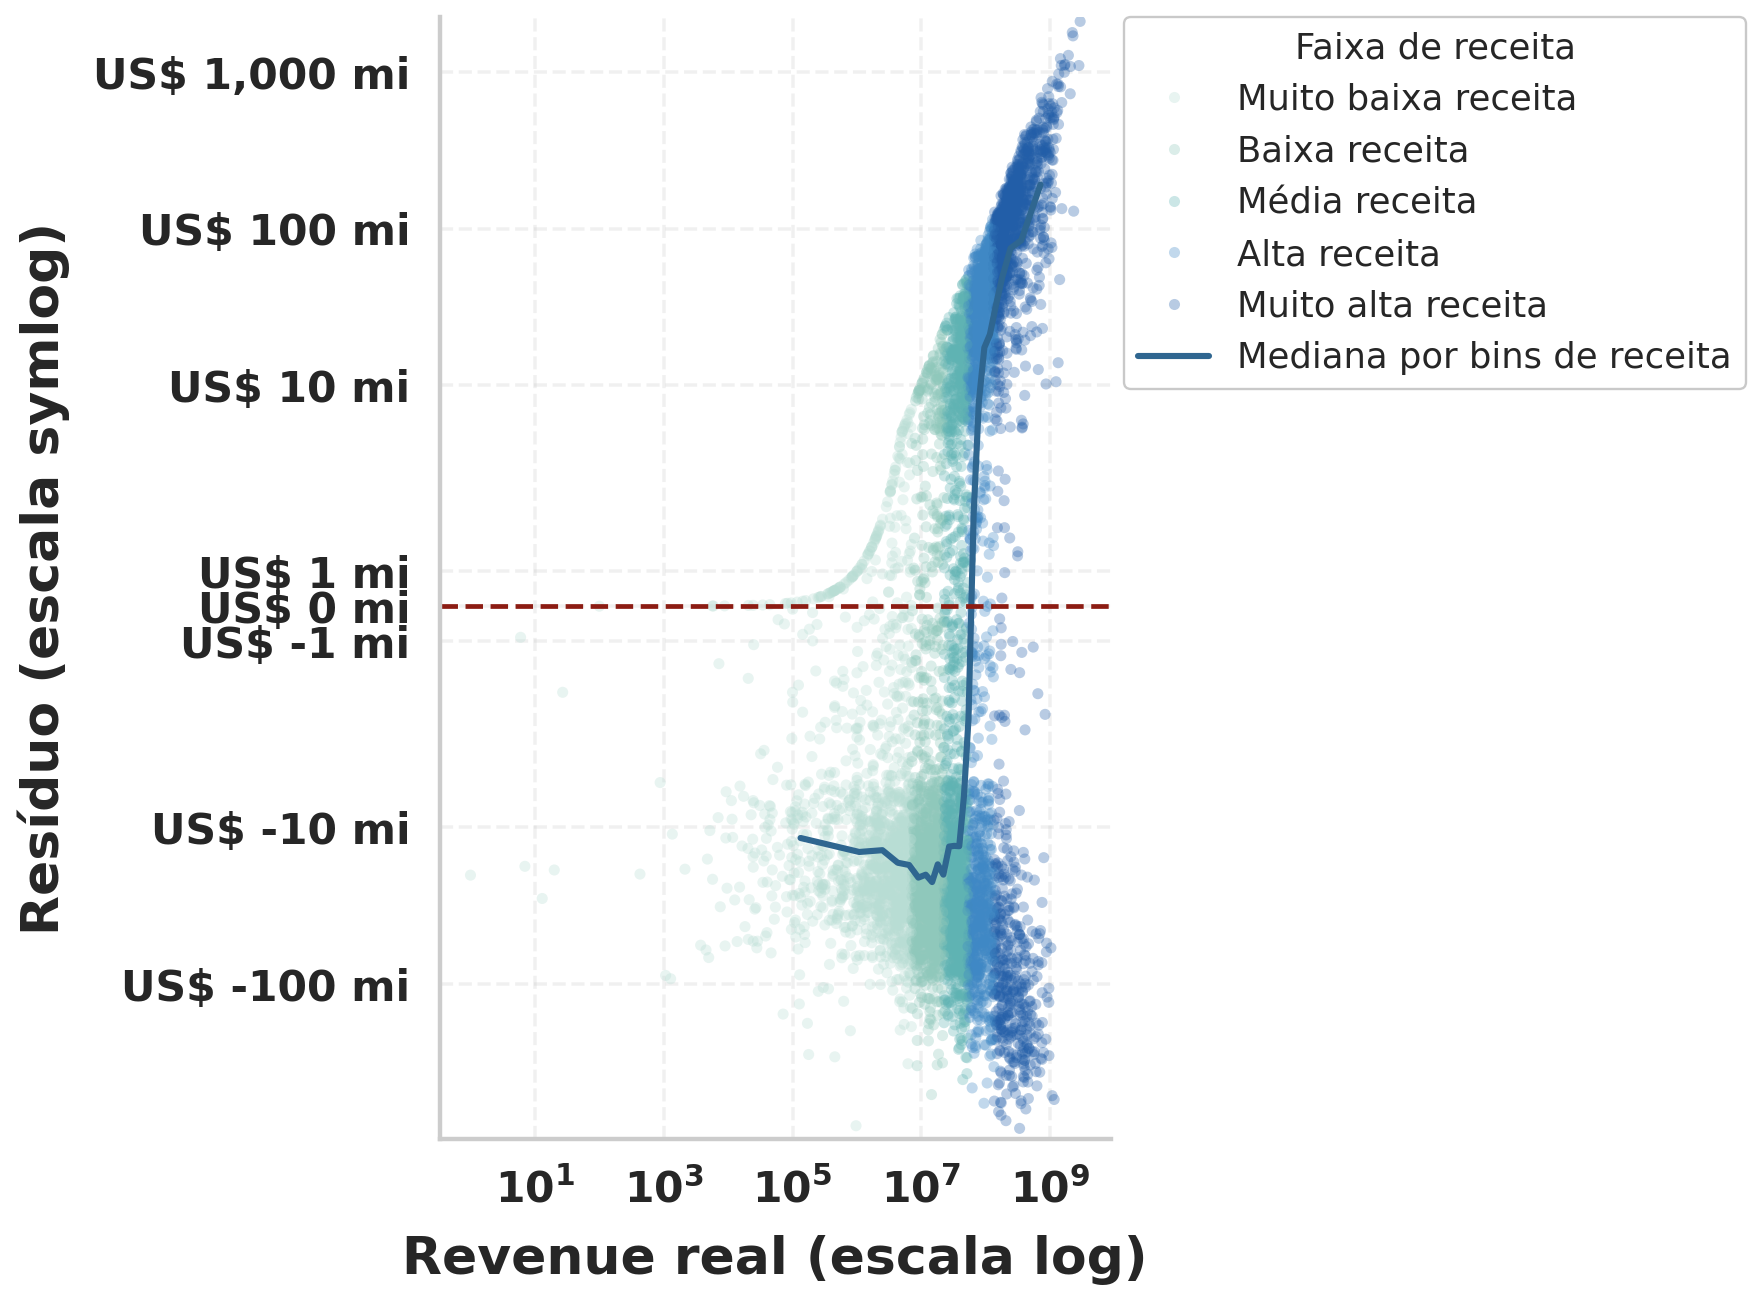

Arquivos de imagem salvos:
- /home/gabriel/Faculdade/Matérias/ML/UFSJ_Aprendizado_Maquina_TP1/code/revenue/images/05_tmdb_extended_no_transform_mae_por_faixa_receita.png
- /home/gabriel/Faculdade/Matérias/ML/UFSJ_Aprendizado_Maquina_TP1/code/revenue/images/05_tmdb_extended_no_transform_boxplot_erro_absoluto_por_faixa.png
- /home/gabriel/Faculdade/Matérias/ML/UFSJ_Aprendizado_Maquina_TP1/code/revenue/images/05_tmdb_extended_no_transform_dispersao_y_true_vs_y_pred.png
- /home/gabriel/Faculdade/Matérias/ML/UFSJ_Aprendizado_Maquina_TP1/code/revenue/images/05_tmdb_extended_no_transform_residuos_vs_y_true.png


In [12]:
figure_title = 'MAE por faixa de receita'
million_axis = FuncFormatter(millions_formatter)
saved_image_paths = []
band_palette_list = [BAND_PALETTE[label] for label in REVENUE_BAND_LABELS]

apply_article_figure_theme()
plt.figure(figsize=(13, 7.4))
ax = sns.barplot(
    data=band_metrics_raw_df,
    x='faixa_receita',
    y='mae_medio',
    hue='faixa_receita',
    order=REVENUE_BAND_LABELS,
    palette=band_palette_list,
    dodge=False,
    width=0.74,
    edgecolor=PLOT_COLORS['text'],
    linewidth=0.8,
)
if ax.legend_ is not None:
    ax.legend_.remove()
ax.yaxis.set_major_formatter(million_axis)
style_axis(ax, 'Faixa de receita', 'MAE médio', xrotation=15, grid_axis='y')
add_bar_value_labels(ax, band_metrics_raw_df['mae_medio'])
plt.tight_layout()
saved_image_paths.append(
    show_and_save_current_figure(
        f'{NOTEBOOK_IMAGE_PREFIX}_mae_por_faixa_receita',
        notebook_title=figure_title,
    )
)

boxplot_df = error_analysis_df.copy()
boxplot_df['abs_error_mi_plot'] = (boxplot_df['abs_error'] / 1_000_000).clip(lower=1e-3)

figure_title = 'Distribuição do erro absoluto por faixa de receita'
apply_article_figure_theme()
plt.figure(figsize=(13, 7.4))
ax = sns.boxplot(
    data=boxplot_df,
    x='faixa_receita',
    y='abs_error_mi_plot',
    hue='faixa_receita',
    order=REVENUE_BAND_LABELS,
    palette=band_palette_list,
    dodge=False,
    width=0.64,
    linewidth=1.3,
    boxprops={'edgecolor': PLOT_COLORS['text']},
    whiskerprops={'color': PLOT_COLORS['text'], 'linewidth': 1.2},
    capprops={'color': PLOT_COLORS['text'], 'linewidth': 1.2},
    medianprops={'color': PLOT_COLORS['red'], 'linewidth': 2.2},
    flierprops={'marker': 'o', 'markersize': 2.8, 'markerfacecolor': PLOT_COLORS['red'], 'markeredgecolor': 'none', 'alpha': 0.10},
)
if ax.legend_ is not None:
    ax.legend_.remove()
ax.set_yscale('log')
style_axis(ax, 'Faixa de receita', 'Erro absoluto (US$ mi, escala log)', xrotation=15, grid_axis='y')
plt.tight_layout()
plt.subplots_adjust(left=0.20)
saved_image_paths.append(
    show_and_save_current_figure(
        f'{NOTEBOOK_IMAGE_PREFIX}_boxplot_erro_absoluto_por_faixa',
        notebook_title=figure_title,
    )
)

plot_df = error_analysis_df.copy()
plot_df['y_true_plot'] = plot_df['y_true'].clip(lower=1)
plot_df['y_pred_plot'] = plot_df['y_pred'].clip(lower=1)
plot_min = max(min(plot_df['y_true_plot'].min(), plot_df['y_pred_plot'].min()), 1)
plot_max = max(plot_df['y_true_plot'].max(), plot_df['y_pred_plot'].max())

figure_title = 'Valores reais vs preditos por faixa de receita'
apply_article_figure_theme()
plt.figure(figsize=(10.8, 8.6))
ax = sns.scatterplot(
    data=plot_df,
    x='y_true_plot',
    y='y_pred_plot',
    hue='faixa_receita',
    hue_order=REVENUE_BAND_LABELS,
    palette=BAND_PALETTE,
    alpha=0.38,
    s=22,
    edgecolor='none',
)
ax.plot([plot_min, plot_max], [plot_min, plot_max], linestyle='--', color=PLOT_COLORS['red'], linewidth=2)
ax.set_xscale('log')
ax.set_yscale('log')
style_axis(ax, 'Revenue real (escala log)', 'Revenue predito (escala log)')
legend = ax.legend(title='Faixa de receita', fontsize=15, title_fontsize=15, loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
style_band_legend(legend)
plt.tight_layout()
saved_image_paths.append(
    show_and_save_current_figure(
        f'{NOTEBOOK_IMAGE_PREFIX}_dispersao_y_true_vs_y_pred',
        notebook_title=figure_title,
    )
)

residual_trend_df = (
    plot_df.assign(revenue_bin=pd.qcut(plot_df['y_true_plot'], q=24, duplicates='drop'))
    .groupby('revenue_bin', observed=False)
    .agg(
        y_true_center=('y_true_plot', 'median'),
        residual_median=('residual', 'median'),
    )
    .dropna()
)

figure_title = 'Resíduos em função da receita real por faixa de receita'
apply_article_figure_theme()
plt.figure(figsize=(10.8, 8.0))
ax = sns.scatterplot(
    data=plot_df,
    x='y_true_plot',
    y='residual',
    hue='faixa_receita',
    hue_order=REVENUE_BAND_LABELS,
    palette=BAND_PALETTE,
    alpha=0.32,
    s=22,
    edgecolor='none',
)
ax.plot(
    residual_trend_df['y_true_center'],
    residual_trend_df['residual_median'],
    color=PLOT_COLORS['navy'],
    linewidth=2.6,
    label='Mediana por bins de receita',
)
ax.axhline(0, linestyle='--', color=PLOT_COLORS['red'], linewidth=2)
ax.set_xscale('log')
ax.set_yscale('symlog', linthresh=5_000_000)
ax.yaxis.set_major_formatter(million_axis)
style_axis(ax, 'Revenue real (escala log)', 'Resíduo (escala symlog)')
legend = ax.legend(title='Faixa de receita', fontsize=15, title_fontsize=15, loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
style_band_legend(legend)
plt.tight_layout()
saved_image_paths.append(
    show_and_save_current_figure(
        f'{NOTEBOOK_IMAGE_PREFIX}_residuos_vs_y_true',
        notebook_title=figure_title,
    )
)

print('Arquivos de imagem salvos:')
for image_path in saved_image_paths:
    print(f'- {image_path}')

In [13]:
all_perm_importances = []

for idx, (model, X_test_fold, y_test_model_fold) in enumerate(all_best_models):
    result = permutation_importance(
        model,
        X_test_fold,
        y_test_model_fold,
        scoring='neg_mean_squared_error',
        n_repeats=10,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )

    perm_df = pd.DataFrame({
        'feature': X_test_fold.columns,
        'importance_mean': result.importances_mean,
        'importance_std': result.importances_std,
    }).sort_values(by='importance_mean', ascending=False)

    perm_df['fold'] = idx
    all_perm_importances.append(perm_df)

final_perm_df = pd.concat(all_perm_importances, ignore_index=True)
display(final_perm_df.head())

,feature,importance_mean,importance_std,fold
0,budget,"13,585,735,968,253,542.00","1,662,186,957,166,444.00",0
1,belongs_to_collection,"2,259,452,586,413,261.00","774,418,621,619,076.62",0
2,runtime,"2,138,483,329,282,867.25","1,035,477,747,908,512.12",0
3,Animation,"2,039,498,077,005,414.50","1,245,883,394,826,618.75",0
4,release_year,"415,482,895,558,246.38","256,839,028,732,979.53",0


Figura: Importância média das features por permutação (XGBoost Regressor | TMDB estendido | Sem transformação)


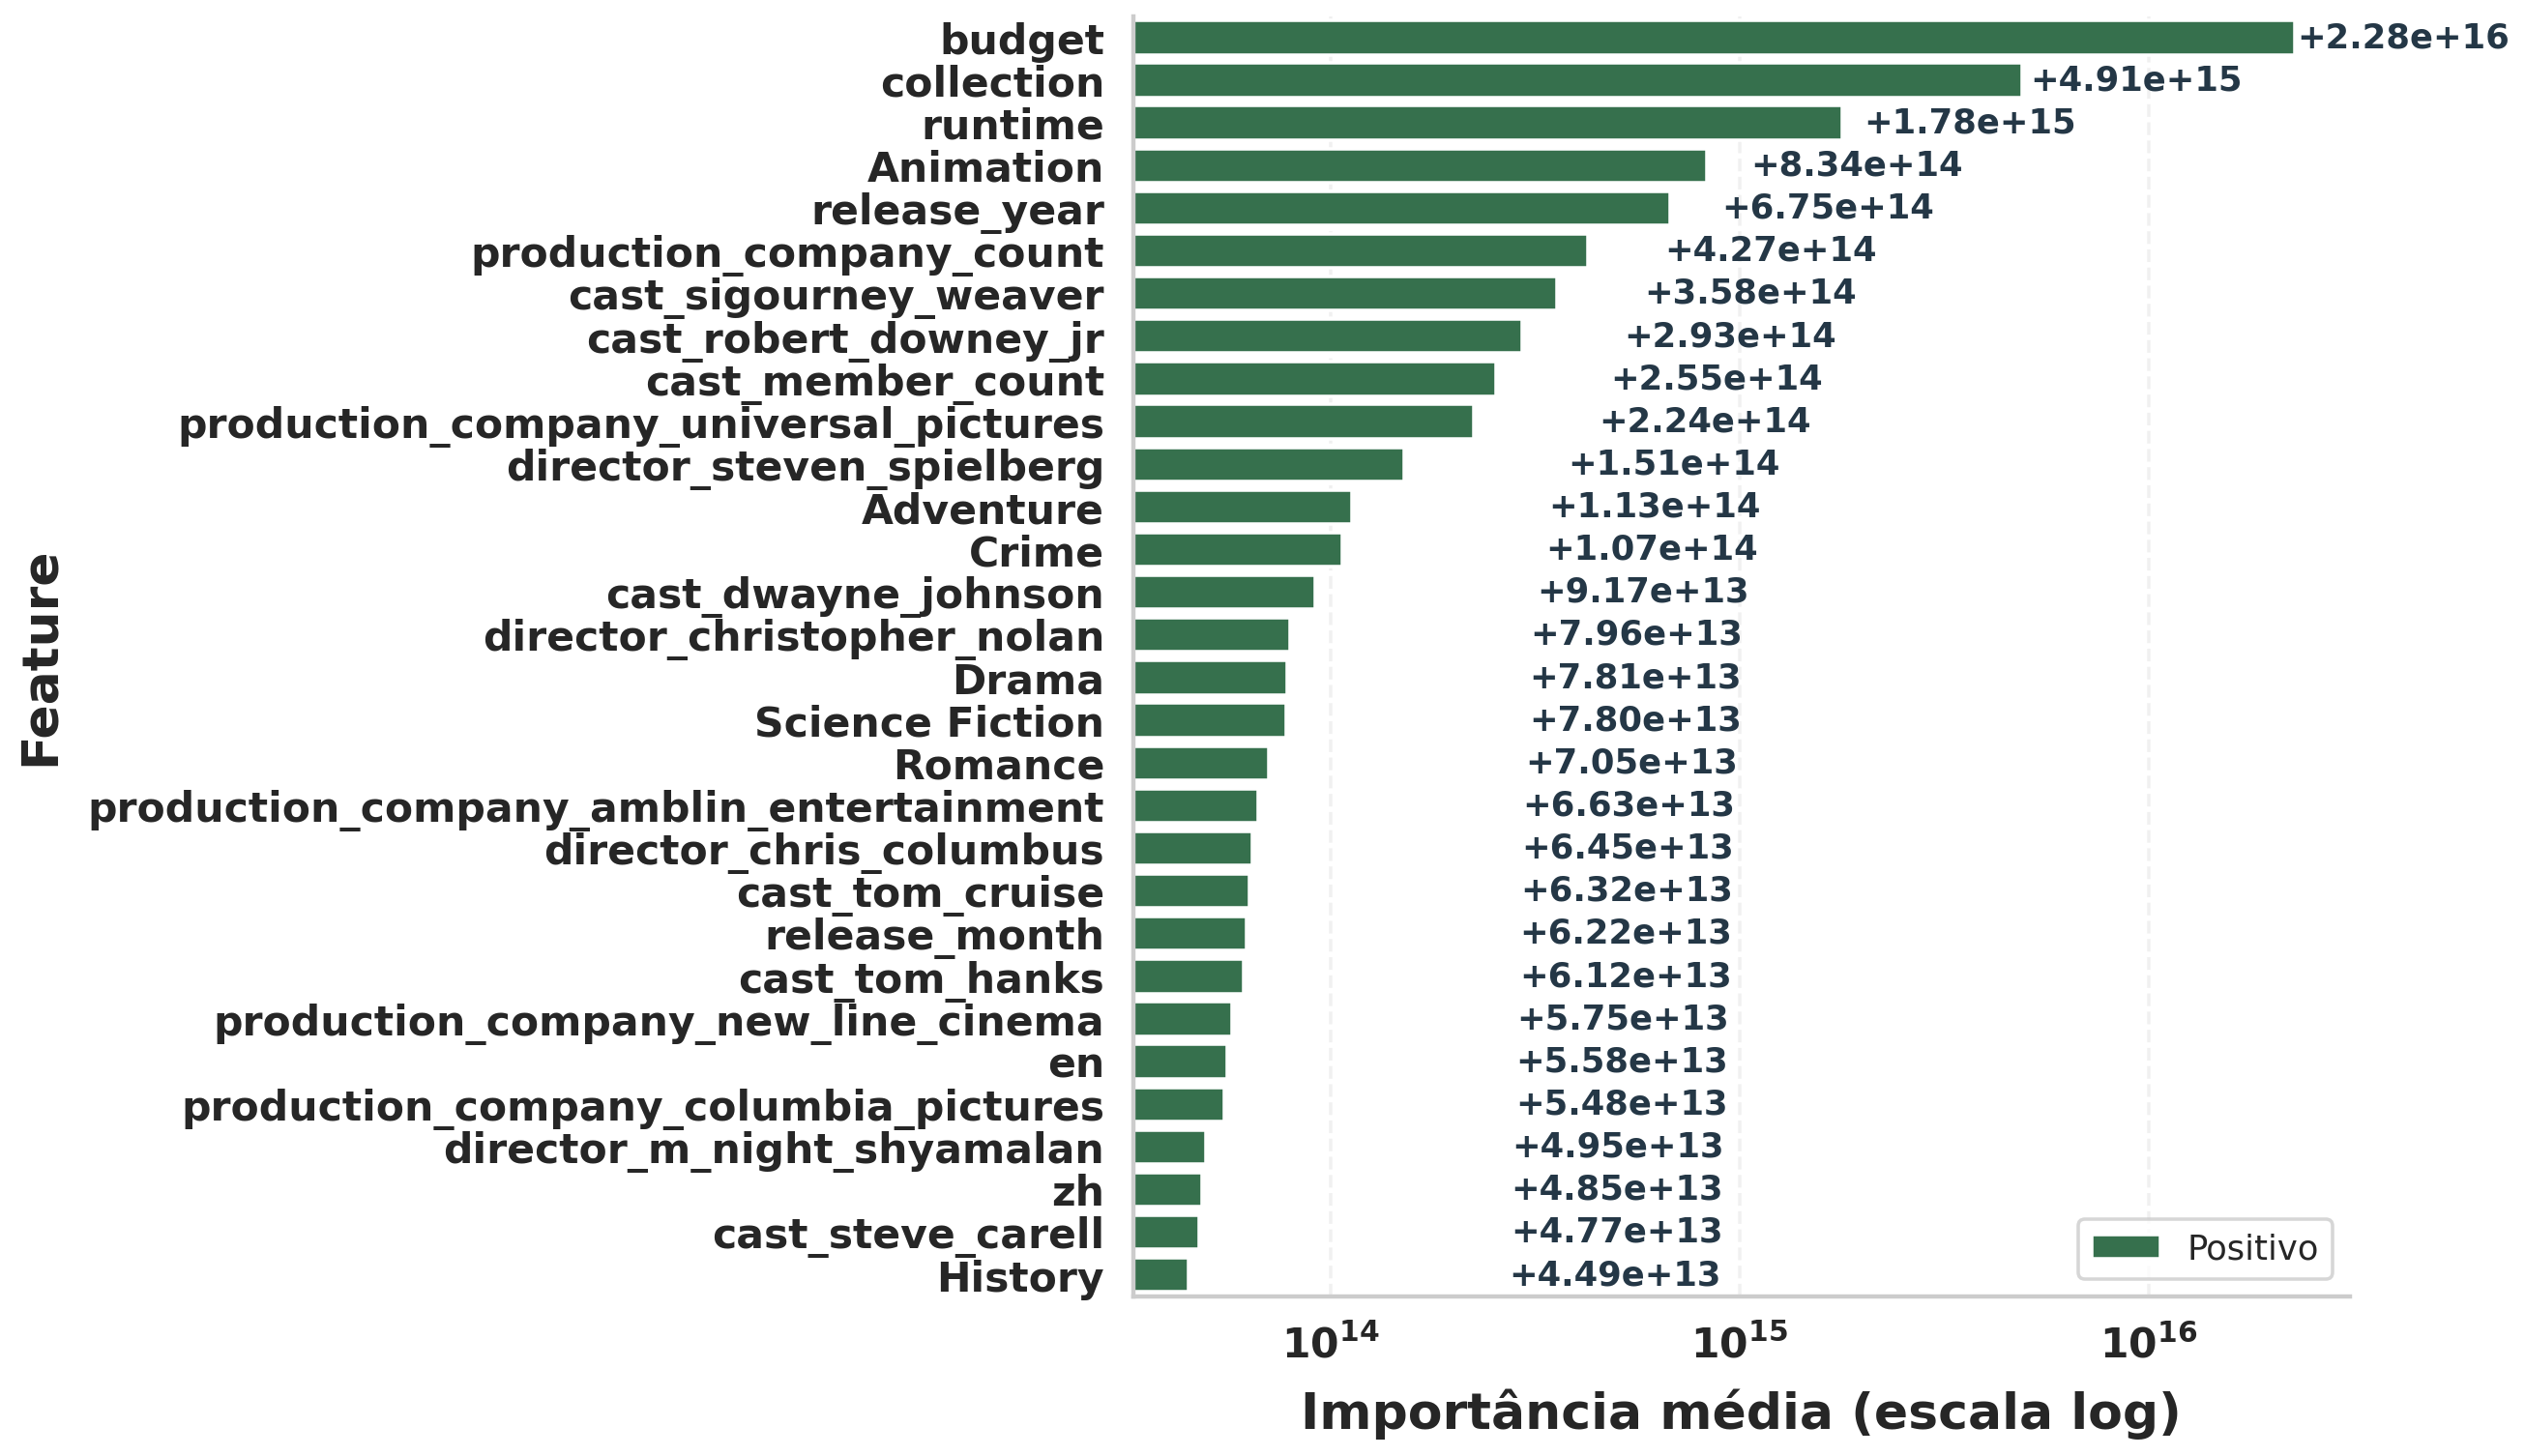

PosixPath('/home/gabriel/Faculdade/Matérias/ML/UFSJ_Aprendizado_Maquina_TP1/code/revenue/images/05_tmdb_extended_no_transform_importancia_media_das_features_por_permutacao.png')

In [14]:
avg_importance = final_perm_df.groupby('feature')['importance_mean'].mean().sort_values(ascending=False)

importance_df = pd.DataFrame({
    'Feature': avg_importance.index,
    'Importancia': avg_importance.values,
    'Signo': ['Positivo' if value >= 0 else 'Negativo' for value in avg_importance.values],
})
importance_df['Feature'] = importance_df['Feature'].replace('belongs_to_collection', 'collection')
importance_df = importance_df[importance_df['Importancia'] != 0].copy()
importance_df['ImportanciaAbs'] = importance_df['Importancia'].abs().clip(lower=1e-12)
importance_df = importance_df.sort_values('ImportanciaAbs', ascending=False).head(30)

palette = {'Positivo': '#2c7a4b', 'Negativo': '#8c1c13'}

figure_title = f'Importância média das features por permutação ({best_model_name} | TMDB estendido | {NOTEBOOK_TARGET_NAME})'
apply_article_figure_theme()
plt.figure(figsize=(15.5, 9.2))
ax = sns.barplot(data=importance_df, x='ImportanciaAbs', y='Feature', hue='Signo', palette=palette, dodge=False)

plt.xlabel('Importância média (escala log)', fontsize=ARTICLE_FIGURE_SIZES['axis_label'], fontweight='semibold', labelpad=10)
plt.ylabel('Feature', fontsize=ARTICLE_FIGURE_SIZES['axis_label'], fontweight='semibold', labelpad=10)
ax.tick_params(axis='x', labelsize=ARTICLE_FIGURE_SIZES['tick'])
ax.tick_params(axis='y', labelsize=ARTICLE_FIGURE_SIZES['tick'])
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('semibold')
plt.grid(axis='x', linestyle='--', alpha=0.28)
ax.legend(title='', fontsize=15, loc='lower right')
ax.set_xscale('log')

max_val = importance_df['ImportanciaAbs'].max()
for i, row in enumerate(importance_df.itertuples(index=False)):
    sign = '+' if row.Importancia >= 0 else '-'
    ax.text(
        row.ImportanciaAbs + 0.01 * max_val,
        i,
        f"{sign}{row.ImportanciaAbs:.2e}",
        color='#243746',
        va='center',
        ha='left',
        fontsize=15,
        fontweight='semibold',
    )
sns.despine(ax=ax)

plt.tight_layout()
show_and_save_current_figure(
    f'{NOTEBOOK_IMAGE_PREFIX}_importancia_media_das_features_por_permutacao',
    notebook_title=figure_title,
)